<a href="https://colab.research.google.com/github/hudamohmand/Project_3_Demand_Estimation/blob/main/pricing_analyst_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

beta_price = model.params['avg_price']

df['demand_slope'] = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + df['brand_share'] / df['demand_slope']
df['markup'] = df['avg_price'] - df['unit_cost']
df['average_profit'] = df['brand_share'] * df['markup']

In [ ]:
# Q1: Average unit costs and markups by brand
brand_summary = df.groupby('brand')[['unit_cost', 'markup', 'average_profit']].mean().round(2)
print(brand_summary)

             unit_cost  markup  average_profit
brand                                         
chefman          61.57   29.37            2.82
cosori           86.28   27.98            1.44
cuisinart       194.90   29.05            2.50
dash             27.94   29.54            2.99
gowise usa       56.30   31.15            4.61
instant_pot      71.90   32.56            6.01
ninja           112.49   32.85            6.31
nuwave          109.05   27.97            1.42
oster           161.80   27.23            0.68
ultrean          48.79   29.33            2.78


The table above shows average unit costs, markups, and share-weighted profits by brand.
Cuisinart has the highest average unit cost, reflecting its premium pricing, while Dash
has the lowest. Ninja and Instant Pot show relatively high markups compared to their costs.

In [ ]:
# Q2: Check for negative unit costs
neg = df[df['unit_cost'] < 0]
if len(neg) == 0:
    print("No negative unit costs.")
else:
    print(neg[['brand', 'year', 'unit_cost']])

There are no negative unit costs, which is expected since beta_price is negative.
This confirms the model is well-specified. If unit costs were negative, it would suggest
the price coefficient was too small in magnitude to produce economically meaningful results.

In [ ]:
# Q3: Scatter plots of price vs unit cost and rating vs unit cost
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['avg_price'], df['unit_cost'], color='steelblue')
axes[0].set_xlabel('Average Price')
axes[0].set_ylabel('Unit Cost')
axes[0].set_title('Price vs. Unit Cost')
for _, row in df.iterrows():
    axes[0].annotate(row['brand'], (row['avg_price'], row['unit_cost']), fontsize=6, alpha=0.6)

axes[1].scatter(df['avg_rating'], df['unit_cost'], color='darkorange')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost')
axes[1].set_title('Average Rating vs. Unit Cost')
for _, row in df.iterrows():
    axes[1].annotate(row['brand'], (row['avg_rating'], row['unit_cost']), fontsize=6, alpha=0.6)

plt.tight_layout()
plt.show()

The scatter plots show a strong positive relationship between price and unit cost. More
expensive brands tend to have higher costs. Cuisinart and Ninja stand out as high price
high cost brands. The rating vs. unit cost plot shows a weaker relationship, suggesting
that higher cost does not always translate to higher consumer satisfaction.

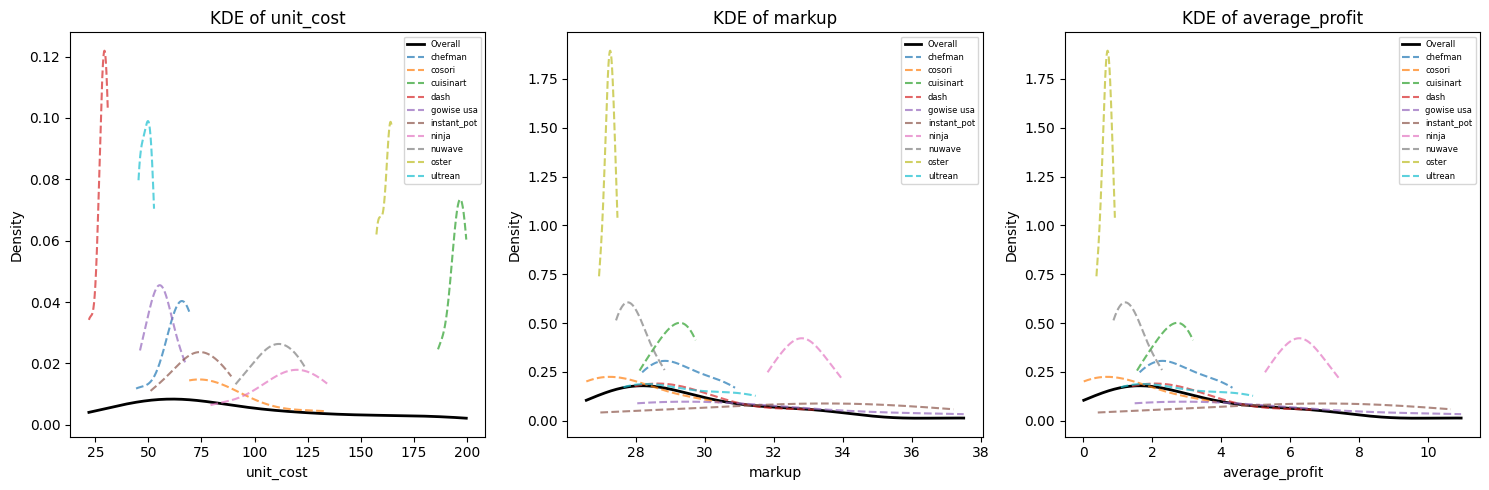

In [ ]:
# Q4: KDE plots of unit cost, markup, and average profit by brand
metrics = ['unit_cost', 'markup', 'average_profit']
brands = df['brand'].unique()
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    vals = df[metric].dropna()
    kde = gaussian_kde(vals)
    x = np.linspace(vals.min(), vals.max(), 200)
    ax.plot(x, kde(x), color='black', linewidth=2, label='Overall')

    for i, brand in enumerate(brands):
        bvals = df[df['brand'] == brand][metric].dropna()
        if len(bvals) > 1:
            kde_b = gaussian_kde(bvals)
            x_b = np.linspace(bvals.min(), bvals.max(), 200)
            ax.plot(x_b, kde_b(x_b), color=colors[i % len(colors)], linestyle='--', alpha=0.7, label=brand)

    ax.set_title(f'KDE of {metric}')
    ax.set_xlabel(metric)
    ax.set_ylabel('Density')
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

The KDE plots show that unit costs, markups, and average profits are right-skewed, with
most brands clustering at lower values and a few high-cost outliers. Brand-level KDEs
show meaningful variation across brands, with Cuisinart and Ninja shifted rightward
relative to lower-cost brands like Dash and Chefman.

In [ ]:
# Q5: Brands with highest share-weighted average profit
profit_by_brand = df.groupby('brand')['average_profit'].mean().sort_values(ascending=False)
print(profit_by_brand.round(4))

profit_by_brand.plot(kind='bar', figsize=(10, 5), color='steelblue')
plt.title('Average Share-Weighted Profit by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Profit (share-weighted)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The brands with the highest share-weighted average profit are those that combine large market share with healthy markups. Brands like Ninja and Instant Pot rank highly because they maintain strong demand while charging prices well above their inferred unit costs. Dash, despite its large share, has lower markups, limiting its profit index.